<a href="https://colab.research.google.com/github/Subir1908/SMS_Spam_Classification/blob/main/spam_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
import pandas as pd

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Spam_classification/spam.csv',encoding='latin-1')

In [83]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [84]:
df.shape

(5572, 5)

In [85]:
#1: Data Cleaning
#2: EDA
#3: Text Preprocessing
#4: Model building
#5: Evaluation
#6: Improvement
#7: Website
#8: Deploy

1. Data Cleaning

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [87]:
# drop last three columns as they are not missing many values as we see above
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [88]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [89]:
df.sample(10)

,v1,v2
5564,ham,Why don't you wait 'til at least wednesday to ...
3620,ham,That means from february to april i'll be gett...
4255,ham,Aah! A cuddle would be lush! I'd need lots of ...
4226,ham,Buy one egg for me da..please:)
2571,ham,Û_ and donÛ÷t worry weÛ÷ll have finished by...
94,ham,Havent planning to buy later. I check already ...
2834,ham,"Ya they are well and fine., BBD(pooja) full pi..."
5289,ham,Hey! Congrats 2u2. id luv 2 but ive had 2 go h...
1905,ham,"There're some people by mu, I'm at the table b..."
2826,ham,"Oh right, ok. I'll make sure that i do loads o..."


In [90]:
#Rename the columns as they do not specify clearly their function
df.rename(columns={'v1':'target', 'v2':'text'},inplace=True)

In [91]:
df.sample(10)

,target,text
5403,ham,So gd got free ice cream... I oso wan...
2588,ham,My superior telling that friday is leave for a...
381,ham,"Yeah sure, give me a couple minutes to track d..."
2231,ham,"K, wen ur free come to my home and also tel vi..."
2205,ham,"Haha, my legs and neck are killing me and my a..."
3410,ham,Only once then after ill obey all yours.
810,ham,S:)s.nervous &lt;#&gt; :)
1677,ham,Lol where do u come up with these ideas?
2482,ham,Pansy! You've been living in a jungle for two ...
1864,ham,You call him now ok i said call him


In [92]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [93]:
encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0])

In [94]:
df['target'] = encoder.fit_transform(df['target'])

In [95]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [96]:
#check for null values
df.isnull().sum()

,0
target,0
text,0


In [97]:
#check for dulplicate values
df.duplicated().sum()

np.int64(403)

In [98]:
#remove duplicates
df = df.drop_duplicates(keep='first')

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.shape

(5169, 2)

2. EDA - Exploratory Data Analysis

In [101]:
df['target'].value_counts()

,count
target,
0,4516
1,653


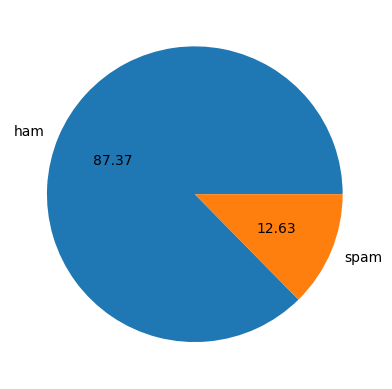

In [102]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [103]:
#Data is imbalanced

In [104]:
!pip install nltk

In [105]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [106]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [107]:
df['num_characters'] = df['text'].apply(len)

In [108]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [109]:
#num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [110]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [111]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [112]:
#Describe the values of the new three columns that are added
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [113]:
#ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [114]:
#spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [115]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

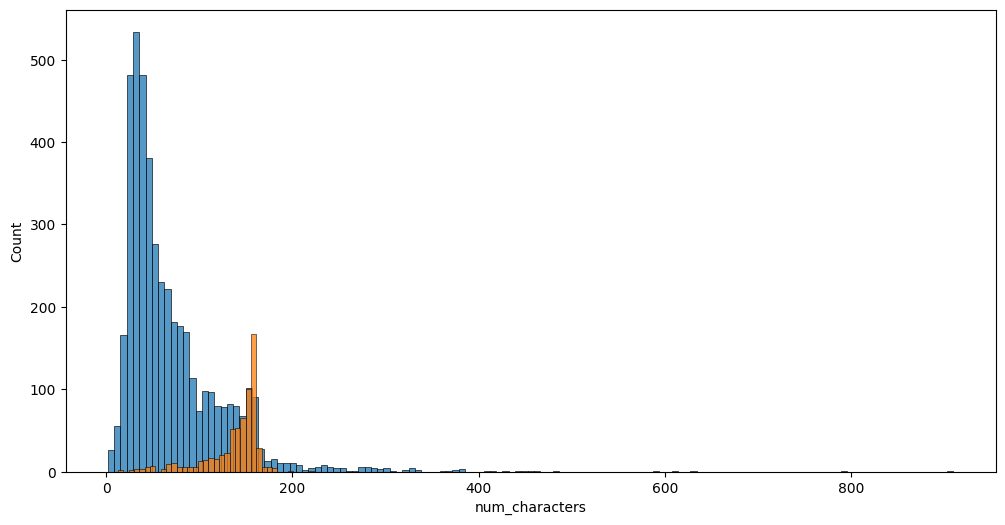

In [116]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'])

<Axes: xlabel='num_words', ylabel='Count'>

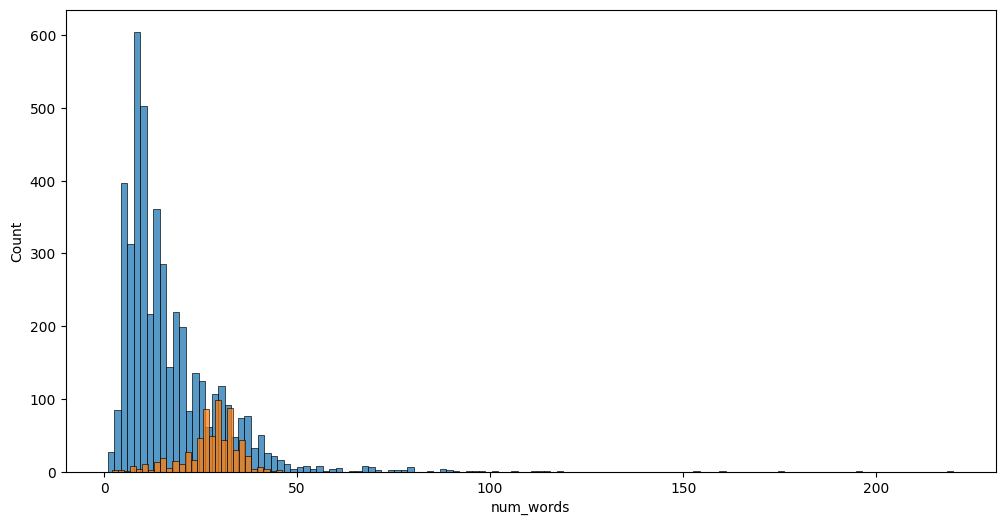

In [117]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'])

<Axes: xlabel='num_sentences', ylabel='Count'>

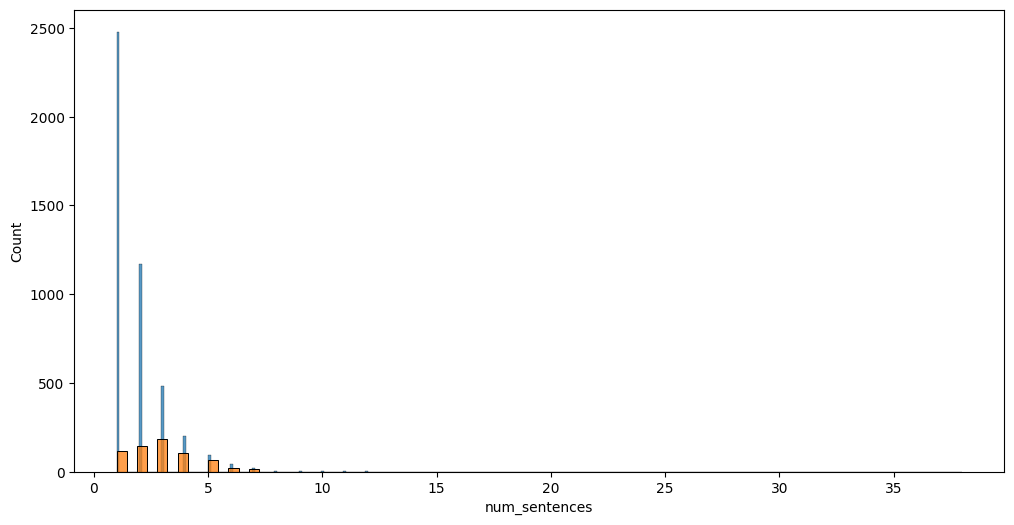

In [118]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sentences'])
sns.histplot(df[df['target'] == 1]['num_sentences'])

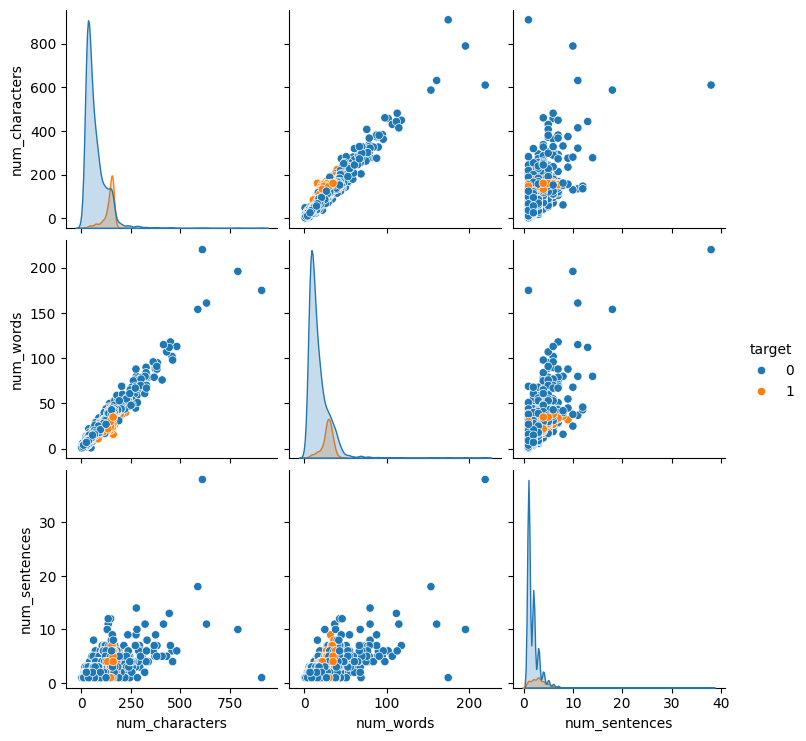

In [119]:
sns.pairplot(df,hue='target')

In [120]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [121]:
df[['target','num_characters','num_words','num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

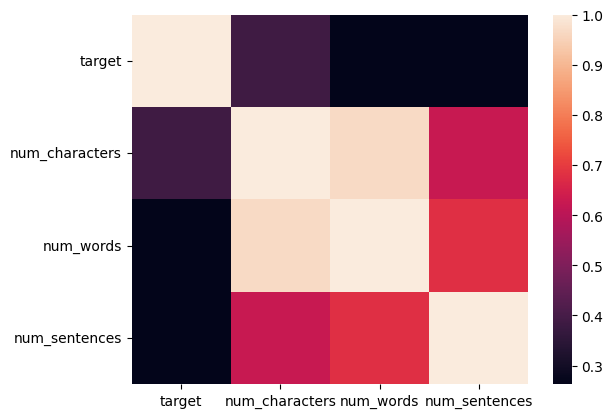

In [122]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr())

<Axes: >

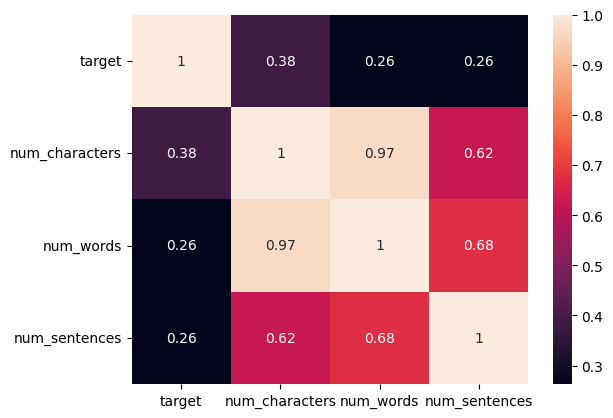

In [123]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

3. Data Preprocessing

*   Lower case
*   Tokenization
*   Removing special characters
*   Removing stop words and punctuation
*   Stemming or Lametization


In [124]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
ps = PorterStemmer()

In [125]:
def preprocess_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      if i not in stopwords.words('english') and i not in string.punctuation:
        y.append(ps.stem(i))
  return " ".join(y)

In [126]:
text = preprocess_text('Hi! How are% You Subir? Do you feel good about the dancing? I personally am loving the experience')
text

'hi subir feel good danc person love experi'

In [127]:
df["preprocessed_text"] = df['text'].apply(preprocess_text)
df.sample(10)

,target,text,num_characters,num_words,num_sentences,preprocessed_text
4464,0,\CHEERS FOR CALLIN BABE.SOZI CULDNT TALKBUT I ...,99,17,1,callin culdnt talkbut wannatel u detail later ...
2606,0,R U &SAM P IN EACHOTHER. IF WE MEET WE CAN GO ...,56,17,2,r u sam p eachoth meet go 2 hous
1846,0,Its on in engalnd! But telly has decided it wo...,107,26,3,engalnd telli decid wo let watch mia elliot ki...
3777,0,Once a fishrman woke early in d mrng. It was v...,302,77,6,fishrman woke earli mrng dark wait amp found s...
5003,0,There's someone here that has a year &lt;#&gt...,247,65,4,someon year lt gt toyota camri like mr olayiwo...
5245,0,Thank you princess! I want to see your nice ju...,58,13,2,thank princess want see nice juici booti
3544,0,Thank You meet you monday,25,5,1,thank meet monday
3798,0,"Actually nvm, got hella cash, we still on for ...",61,20,1,actual nvm got hella cash still lt gt ish
2346,0,Its posible dnt live in &lt;#&gt; century cm ...,67,18,1,posibl dnt live lt gt centuri cm frwd n thnk d...
3697,0,S:)but he had some luck.2 catches put down:),44,13,1,catch put


In [128]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size = 10, background_color="white")

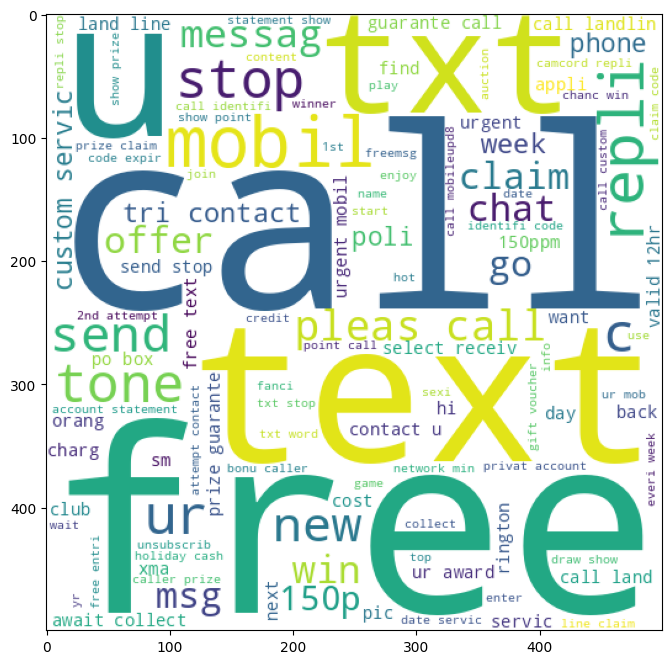

In [129]:
spam_wc = wc.generate(df[df['target'] == 1]['preprocessed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,8))
plt.imshow(spam_wc)

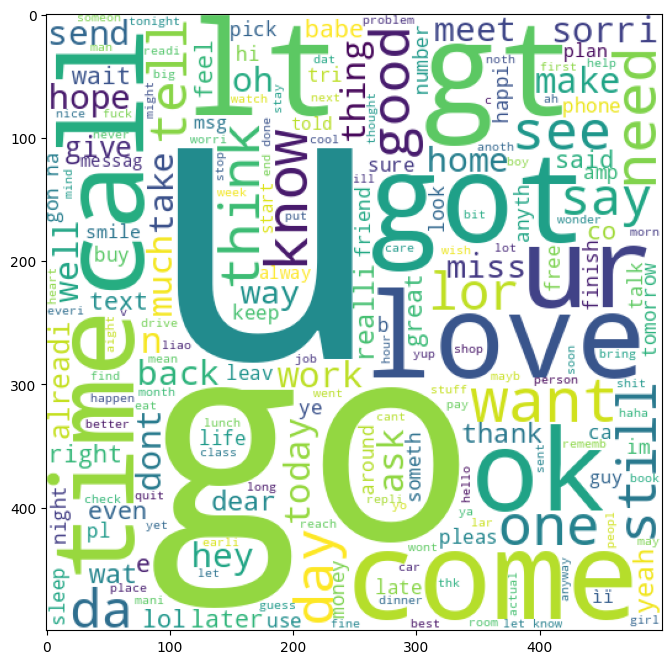

In [130]:
ham_pc = wc.generate(df[df['target'] == 0]['preprocessed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,8))
plt.imshow(ham_pc)

In [131]:
spam_corpus = []
for msg in df[df['target'] == 1]['preprocessed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [132]:
len(spam_corpus)

9939

In [133]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [134]:
from collections import Counter

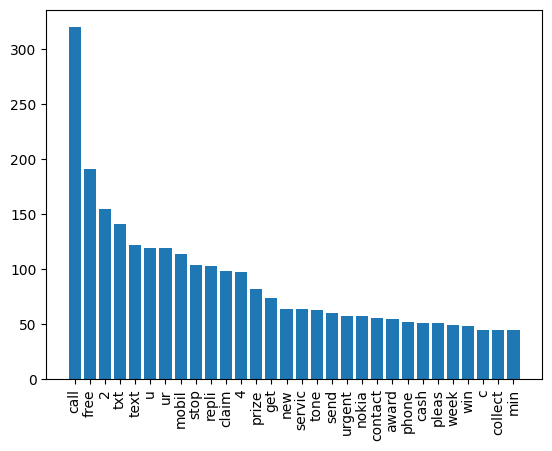

In [135]:
plt.bar(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [136]:
ham_corpus = []
for msg in df[df['target'] == 0]['preprocessed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [137]:
len(ham_corpus)

35404

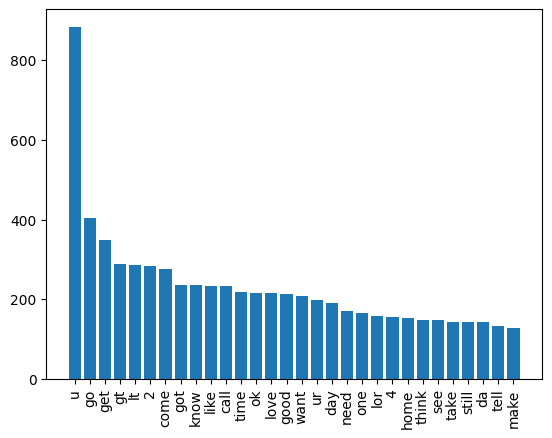

In [138]:
plt.bar(pd.DataFrame(Counter(ham_corpus).most_common(30))[0],pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# **4. Model Building**

In [139]:
# We start by vectorizing our text using the Bag of Words Method
# We use the Naive Bayes Model as it performs the best in case of texts
df.head()

,target,text,num_characters,num_words,num_sentences,preprocessed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [140]:
df[df['target']==0]['preprocessed_text']

,preprocessed_text
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
6,even brother like speak treat like aid patent
...,...
5565,huh lei
5568,b go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [186]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features=3000)

In [187]:
X = tf.fit_transform(df['preprocessed_text']).toarray()
X.shape

(5169, 3000)

In [189]:
# from sklearn.processing import MinMaxScaler
# scaler = MinMaxScaler()
# X = scaler.fir_transform(X)

In [175]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [176]:
from sklearn.model_selection import train_test_split

In [177]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [195]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [196]:
# gnb = GaussianNB()
mnb = MultinomialNB()
# bnb = BernoulliNB()

In [197]:
# gnb.fit(X_train,y_train)
# y_pred1 = gnb.predict(X_test)
# print(accuracy_score(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))

In [198]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.9709864603481625
1.0
[[896   0]
 [ 30 108]]


In [199]:
# bnb.fit(X_train,y_train)
# y_pred3 = bnb.predict(X_test)
# print(accuracy_score(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))

In [200]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.svm import LinearSVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import ExtraTreesClassifier,GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
# from xgboost import XGBClassifier

In [201]:
# svc = LinearSVC(random_state=0)
# mnb = MultinomialNB()
# knc = KNeighborsClassifier()
# dtc = DecisionTreeClassifier(max_depth=5)
# lrc = LogisticRegression(solver='liblinear',penalty='l1')
# rfc = RandomForestClassifier(n_estimators=50,random_state=2)
# abc = AdaBoostClassifier(n_estimators=50,random_state=2)
# bc = BaggingClassifier(n_estimators=50,random_state=2)
# etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
# gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
# xgb = XGBClassifier(n_estimators=50,random_state=2)

In [202]:
# clfs = {
#     'SVC':svc,
#     'KN':knc,
#     'MNB':mnb,
#     'DT':dtc,
#     'LR':lrc,
#     'RF':rfc,
#     'AdaBoost':abc,
#     'BgC':bc,
#     'ETC':etc,
#     'GBDT':gbdt,
#     'xgb':xgb
# }

In [203]:
# def train_classifier(clf,X_train,y_train,X_test,y_test):
#   clf.fit(X_train,y_train)
#   y_pred = clf.predict(X_test)
#   accuracy = accuracy_score(y_test,y_pred)
#   precision = precision_score(y_test, y_pred)
#   return accuracy,precision

In [204]:
# train_classifier(mnb,X_train,y_train,X_test,y_test)

In [205]:
# accuracy_scores = []
# precision_scores = []

# for name,clf in clfs.items():
#   current_accuracy, current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

#   accuracy_scores.append(current_accuracy)
#   precision_scores.append(current_precision)

In [206]:
# performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [207]:
# We sort this by descending order of precision as precision matters more than accuracy in text based data
# performance_df

In [208]:
# Now we try to improve the model performance
# 1. Changing th max_feature parameter
# 2. Integrating MinMax Scaling
# 3. Voting Classifier (sometimes perform better than best model)
# 4. Applying Stacking

In [209]:
# We finally use Multinomial NB as it perfoms the best

In [210]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))